# **1. Perkenalan Dataset**

Dataset yang digunakan dalam eksperimen ini adalah **Wine Quality Dataset** dari UCI Machine Learning Repository.
Dataset ini mencakup dua jenis wine, yaitu **Red Wine** dan **White Wine**, dengan fitur-fitur kimiawi yang merepresentasikan kualitas wine tersebut.

**Tujuan Eksperimen**:
Membangun model klasifikasi biner untuk memprediksi apakah suatu wine memiliki kualitas yang baik (`good_quality` >= 6) atau tidak (< 6).


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

print('Library successfully imported.')

Library successfully imported.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load Red and White Wine datasets
red_wine = pd.read_csv('winequality_raw/winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality_raw/winequality-white.csv', sep=';')

# Add type column (1 for red, 0 for white)
red_wine['type'] = 1
white_wine['type'] = 0

# Merge datasets
df = pd.concat([red_wine, white_wine], ignore_index=True)

# Display basic info
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB

--- Missing Values ---
fixed acidity           0
vola

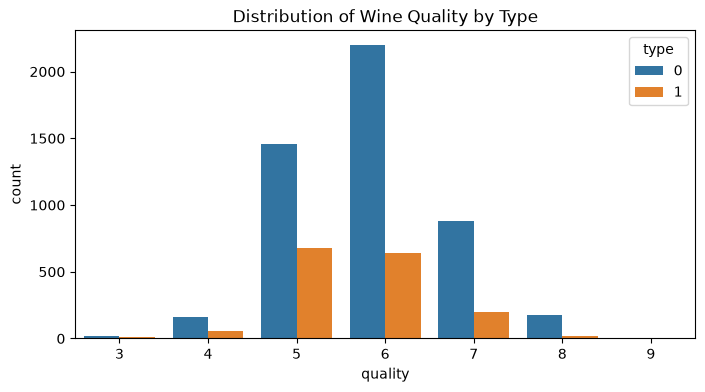

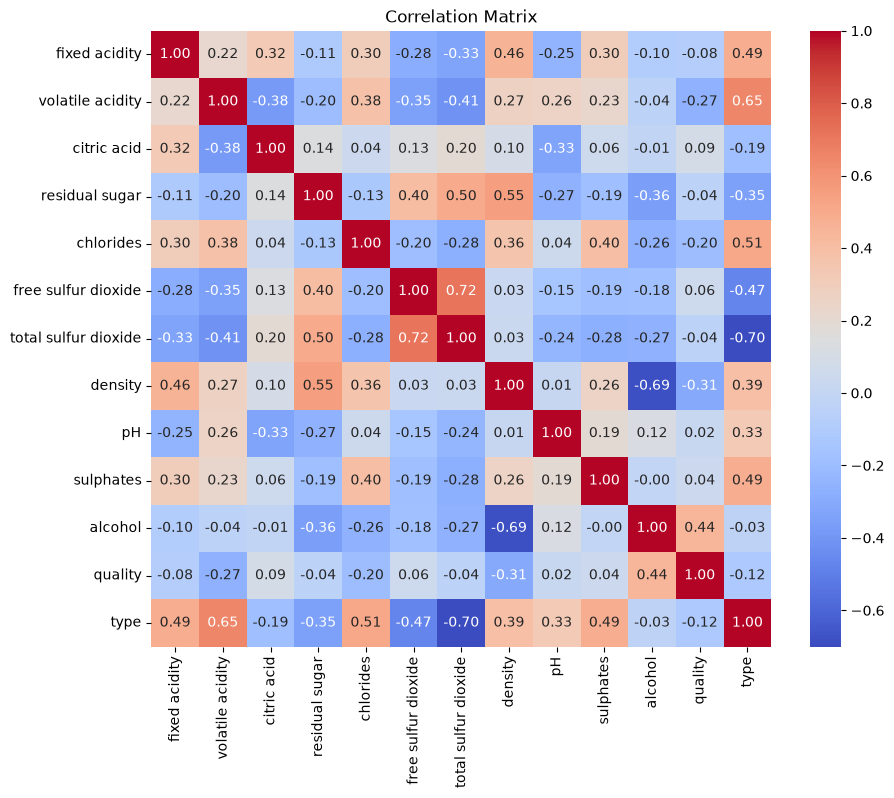

In [3]:
# Check dataset info and missing values
print('--- Dataset Info ---')
df.info()

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Class Distribution (Quality) ---')
print(df['quality'].value_counts())

# Plotting distribution of Wine Quality by Type
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, hue='type')
plt.title('Distribution of Wine Quality by Type')
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Convert to binary classification (good_quality: 1 for quality >= 6, else 0)
df['good_quality'] = (df['quality'] >= 6).astype(int)
df = df.drop('quality', axis=1)

# Remove duplicate rows
print(f'Duplicate rows found: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

# Deteksi dan Penanganan Outlier menggunakan metode IQR (Capping)
num_cols = df.select_dtypes(include=[np.number]).columns.drop(['good_quality', 'type'])
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[col] = np.clip(df[col], lower_bound, upper_bound)
print('Outliers handled by capping at 1.5 IQR bounds.')

# Train-test split (80% train, 20% test)
X = df.drop('good_quality', axis=1)
y = df['good_quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization of numerical features (excluding target and binary columns)
scaler = StandardScaler()
scale_cols = X.columns.drop('type')

# Standardize training set scale columns
X_train_scaled_vals = scaler.fit_transform(X_train[scale_cols])
X_test_scaled_vals = scaler.transform(X_test[scale_cols])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = X_train_scaled_vals
X_test_scaled[scale_cols] = X_test_scaled_vals

# Concatenate features and targets
train_processed = pd.concat([X_train_scaled, y_train], axis=1)
test_processed = pd.concat([X_test_scaled, y_test], axis=1)

# Save processed datasets and scaler
os.makedirs('winequality_preprocessing', exist_ok=True)
train_processed.to_csv('winequality_preprocessing/train_processed.csv', index=False)
test_processed.to_csv('winequality_preprocessing/test_processed.csv', index=False)
joblib.dump(scaler, 'winequality_preprocessing/scaler.joblib')

print('Train shape:', train_processed.shape)
print('Test shape:', test_processed.shape)
print('Scaler and preprocessed datasets saved successfully.')

Duplicate rows found: 1177
Shape after removing duplicates: (5320, 13)
Outliers handled by capping at 1.5 IQR bounds.
Train shape: (4256, 13)
Test shape: (1064, 13)
Scaler and preprocessed datasets saved successfully.
